In [12]:
import os
import numpy as np
import joblib
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [43]:
PROCESSED_DIR = "data/processed"
MODELS_DIR    = "models"
PLOTS_DIR     = "data/processed/plots"

SEQ_LEN       = 96
N_FEATURES    = 13
DEVICE        = torch.device(
                        "cuda" if torch.cuda.is_available()
                        else "mps" if torch.backends.mps.is_available()
                        else "cpu"
                    )

# Model hyperparameters (sized for ~470 samples)
ENCODER_HIDDEN = 16
DECODER_HIDDEN = 16
NUM_LAYERS     = 1
DROPOUT        = 0.4

# Training hyperparameters
EPOCHS         = 150
BATCH_SIZE     = 96
LR             = 1e-3
EARLY_STOP     = 15   # stop if val MAE doesn't improve for 15 epochs

In [31]:
class EnergyDataset(Dataset):
    def __init__(self, X, y):
        # X: (n_days, 96, 7) — kept as 3D (no flattening needed for LSTM)
        # y: (n_days, 96)
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [32]:
class BahdanauAttention(nn.Module):
    """
    Additive (Bahdanau) attention.
    At each decoder step t, computes a weighted sum over all 96
    encoder hidden states — dynamic context vector c_t.
    """
    def __init__(self, encoder_hidden_dim, decoder_hidden_dim):
        super().__init__()
        self.W_encoder = nn.Linear(encoder_hidden_dim, decoder_hidden_dim, bias=False)
        self.W_decoder = nn.Linear(decoder_hidden_dim, decoder_hidden_dim, bias=False)
        self.v         = nn.Linear(decoder_hidden_dim, 1, bias=False)

    def forward(self, encoder_outputs, decoder_hidden):
        # encoder_outputs: (batch, 96, encoder_hidden_dim)
        # decoder_hidden:  (batch, decoder_hidden_dim)
        energy  = torch.tanh(
            self.W_encoder(encoder_outputs) +                        # (batch, 96, dec_hid)
            self.W_decoder(decoder_hidden).unsqueeze(1)              # (batch,  1, dec_hid)
        )
        weights = torch.softmax(self.v(energy).squeeze(-1), dim=-1)  # (batch, 96)
        context = torch.bmm(
            weights.unsqueeze(1), encoder_outputs                    # (batch, 1, enc_hid)
        ).squeeze(1)                                                  # (batch, enc_hid)
        return context, weights

In [33]:
class BiLSTMAttentionModel(nn.Module):
    """
    Architecture:
        Input  (batch, 96, 7)
          ↓
        Bi-LSTM Encoder  →  96 hidden states (batch, 96, 2*encoder_hidden)
          ↓
        Attention + LSTMCell Decoder  →  step-by-step over 96 output timesteps
          ↓
        Linear projection  →  (batch, 96)
    """
    def __init__(self, input_features=N_FEATURES, seq_len=SEQ_LEN,
                 encoder_hidden=ENCODER_HIDDEN, decoder_hidden=DECODER_HIDDEN,
                 num_layers=NUM_LAYERS, dropout=DROPOUT):
        super().__init__()
        self.seq_len    = seq_len
        enc_out_dim     = encoder_hidden * 2   # bidirectional doubles dim

        # Encoder
        self.encoder = nn.LSTM(
            input_size   = input_features,
            hidden_size  = encoder_hidden,
            num_layers   = num_layers,
            batch_first  = True,
            bidirectional= True,
            dropout      = dropout if num_layers > 1 else 0
        )

        # Project encoder final state → decoder initial state
        self.enc2dec = nn.Linear(enc_out_dim, decoder_hidden)

        # Attention
        self.attention = BahdanauAttention(enc_out_dim, decoder_hidden)

        # Decoder cell
        # Input = context vector (enc_out_dim) + encoder step (enc_out_dim)
        self.decoder_cell = nn.LSTMCell(
            input_size  = enc_out_dim + enc_out_dim,
            hidden_size = decoder_hidden
        )
        self.dropout     = nn.Dropout(dropout)

        # Output projection: decoder hidden → scalar per timestep
        self.output_proj = nn.Linear(decoder_hidden, 1)

    def forward(self, x):
        # x: (batch, 96, 7)
        enc_out, (h_n, _) = self.encoder(x)
        # enc_out: (batch, 96, 2*encoder_hidden)
        # h_n:     (2*num_layers, batch, encoder_hidden)

        # Decoder init: concat last forward + backward layer
        h_init     = torch.tanh(
            self.enc2dec(torch.cat([h_n[-2], h_n[-1]], dim=1))
        )  # (batch, decoder_hidden)
        c_init     = torch.zeros_like(h_init)

        dec_hidden = h_init
        dec_cell   = c_init
        predictions = []

        for t in range(self.seq_len):
            context, _   = self.attention(enc_out, dec_hidden)
            dec_input    = torch.cat([context, enc_out[:, t, :]], dim=1)
            dec_hidden, dec_cell = self.decoder_cell(
                self.dropout(dec_input), (dec_hidden, dec_cell)
            )
            predictions.append(self.output_proj(dec_hidden))  # (batch, 1)

        return torch.cat(predictions, dim=1)  # (batch, 96)

In [34]:
def load_splits():
    def load(name):
        X = np.load(os.path.join(PROCESSED_DIR, f"X_{name}.npy"))
        y = np.load(os.path.join(PROCESSED_DIR, f"y_{name}.npy"))
        return X, y

    train = load("train")
    val   = load("val")
    test  = load("test")
    y_raw = np.load(os.path.join(PROCESSED_DIR, "test_y_raw.npy"))
    scaler_y = joblib.load(os.path.join(MODELS_DIR, "scaler_y.pkl"))

    return train, val, test, y_raw, scaler_y

In [35]:
def train(model, train_loader, val_loader):
    print(f"[1/3] Training Bi-LSTM + Attention  (device: {DEVICE})")
    print(f"  Parameters: {sum(p.numel() for p in model.parameters()):,}")

    optimizer  = torch.optim.Adam(model.parameters(), lr=LR)
    scheduler  = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, patience=5, factor=0.5
    )
    criterion  = nn.L1Loss()   # MAE loss — robust to energy price spikes

    best_val_loss = float("inf")
    best_state    = None
    patience_cnt  = 0
    history       = {"train": [], "val": []}

    for epoch in range(EPOCHS):
        # — Train —
        model.train()
        train_loss = 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            optimizer.zero_grad()
            preds = model(X_batch)
            loss  = criterion(preds, y_batch)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_loss += loss.item()
        train_loss /= len(train_loader)

        # — Validate —
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
                val_loss += criterion(model(X_batch), y_batch).item()
        val_loss /= len(val_loader)

        scheduler.step(val_loss)
        history["train"].append(train_loss)
        history["val"].append(val_loss)

        # — Early stopping —
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state    = {k: v.clone() for k, v in model.state_dict().items()}
            patience_cnt  = 0
        else:
            patience_cnt += 1

        if (epoch + 1) % 10 == 0:
            print(f"  Epoch {epoch+1:3d} | "
                  f"Train MAE: {train_loss:.4f} | "
                  f"Val MAE: {val_loss:.4f} | "
                  f"Patience: {patience_cnt}/{EARLY_STOP}")

        if patience_cnt >= EARLY_STOP:
            print(f"  Early stopping at epoch {epoch + 1}")
            break

    print(f"  Best Val MAE: {best_val_loss:.4f}")
    model.load_state_dict(best_state)   # restore best weights
    return model, history

In [36]:
def evaluate(model, X, y_true_raw, scaler_y, split_name="Test"):
    print(f"\n[2/3] Evaluating on {split_name} set ...")
    model.eval()
    with torch.no_grad():
        X_t      = torch.tensor(X, dtype=torch.float32).to(DEVICE)
        y_pred_sc = model(X_t).cpu().numpy()

    y_pred = scaler_y.inverse_transform(y_pred_sc)

    mae   = mean_absolute_error(y_true_raw, y_pred)
    rmse  = np.sqrt(mean_squared_error(y_true_raw, y_pred))
    smape = np.mean(
        2 * np.abs(y_true_raw - y_pred) /
        (np.abs(y_true_raw) + np.abs(y_pred) + 1e-8)
    ) * 100
    mase_denom = np.mean(np.abs(np.diff(y_true_raw, axis=0)))
    mase  = mae / mase_denom if mase_denom > 0 else float("nan")

    print(f"  {'─'*35}")
    print(f"  MAE:   {mae:.4f}")
    print(f"  RMSE:  {rmse:.4f}")
    print(f"  sMAPE: {smape:.2f}%")
    print(f"  MASE:  {mase:.4f}  (< 1.0 beats naive baseline)")
    print(f"  {'─'*35}")
    return y_pred


In [44]:
def plot_training_curve(history, save=True):
    import matplotlib.pyplot as plt
    os.makedirs(PLOTS_DIR, exist_ok=True)

    epochs = range(1, len(history["train"]) + 1)
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(epochs, history["train"], label="Train MAE", color="royalblue", linewidth=2)
    ax.plot(epochs, history["val"],   label="Val MAE",   color="darkorange",
            linewidth=2, linestyle="--")
    ax.set_title("Bi-LSTM + Attention — Training Curve")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("MAE (scaled)")
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    if save:
        path = os.path.join(PLOTS_DIR, "bilstm_training_curve.png")
        plt.savefig(path, dpi=150)
        print(f"  Saved → {path}")
    plt.show()


def plot_single_day(y_true, y_pred, day_idx=0, save=True):
    import matplotlib.pyplot as plt
    os.makedirs(PLOTS_DIR, exist_ok=True)
    quarters = range(SEQ_LEN)

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(quarters, y_true[day_idx], label="Actual",    color="black",     linewidth=2.5)
    ax.plot(quarters, y_pred[day_idx], label="Predicted", color="royalblue", linewidth=2,
            linestyle="--")
    ax.fill_between(quarters, y_true[day_idx], y_pred[day_idx],
                    alpha=0.12, color="royalblue")
    mae_d = np.mean(np.abs(y_true[day_idx] - y_pred[day_idx]))
    ax.set_title(f"Bi-LSTM — Actual vs Predicted | Test Day {day_idx}  "
                 f"(MAE = {mae_d:.4f})", fontsize=13)
    ax.set_xlabel("Quarter-hour  (0 = 00:00 → 95 = 23:45)")
    ax.set_ylabel("Target value")
    ax.legend(fontsize=11)
    ax.grid(alpha=0.3)
    for h in range(0, SEQ_LEN, 4):
        ax.axvline(h, color="gray", linewidth=0.4, linestyle=":")
    plt.tight_layout()
    if save:
        path = os.path.join(PLOTS_DIR, f"bilstm_day_{day_idx}.png")
        plt.savefig(path, dpi=150)
        print(f"  Saved → {path}")
    plt.show()


def plot_full_series(y_true, y_pred, max_days=30, save=True):
    import matplotlib.pyplot as plt
    os.makedirs(PLOTS_DIR, exist_ok=True)
    n      = min(max_days, len(y_true))
    actual = y_true[:n].flatten()
    pred   = y_pred[:n].flatten()
    t      = range(len(actual))

    fig, axes = plt.subplots(2, 1, figsize=(18, 8),
                             gridspec_kw={"height_ratios": [3, 1]})
    axes[0].plot(t, actual, label="Actual",    color="black",     linewidth=1.2)
    axes[0].plot(t, pred,   label="Predicted", color="royalblue", linewidth=1.0,
                 linestyle="--", alpha=0.85)
    axes[0].set_title(f"Bi-LSTM — Continuous Forecast (test, first {n} days)",
                      fontsize=13)
    axes[0].set_ylabel("Target value")
    axes[0].legend(fontsize=10)
    axes[0].grid(alpha=0.25)
    for d in range(0, n * SEQ_LEN, SEQ_LEN):
        axes[0].axvline(d, color="gray", linewidth=0.4, linestyle=":")

    residuals = actual - pred
    axes[1].bar(t, residuals,
                color=np.where(residuals >= 0, "steelblue", "tomato"),
                width=1.0, alpha=0.7)
    axes[1].axhline(0, color="black", linewidth=0.8)
    axes[1].set_ylabel("Residual\n(actual − pred)")
    axes[1].set_xlabel("Quarter-hour index")
    axes[1].grid(alpha=0.2)
    plt.tight_layout()
    if save:
        path = os.path.join(PLOTS_DIR, f"bilstm_series_{n}days.png")
        plt.savefig(path, dpi=150)
        print(f"  Saved → {path}")
    plt.show()


In [37]:
def save_model(model):
    print("\n[3/3] Saving model ...")
    os.makedirs(MODELS_DIR, exist_ok=True)
    path = os.path.join(MODELS_DIR, "bilstm.pt")
    torch.save(model.state_dict(), path)
    print(f"  Saved → {path}")

Device: mps
Train: (360, 96, 13) | Val: (77, 96, 13) | Test: (78, 96, 13)
[1/3] Training Bi-LSTM + Attention  (device: mps)
  Parameters: 37,985
  Epoch  10 | Train MAE: 0.2452 | Val MAE: 1.5658 | Patience: 0/15
  Epoch  20 | Train MAE: 0.1961 | Val MAE: 1.5409 | Patience: 2/15
  Epoch  30 | Train MAE: 0.1752 | Val MAE: 1.5328 | Patience: 1/15
  Epoch  40 | Train MAE: 0.1528 | Val MAE: 1.5101 | Patience: 0/15
  Epoch  50 | Train MAE: 0.1398 | Val MAE: 1.5016 | Patience: 0/15
  Epoch  60 | Train MAE: 0.1287 | Val MAE: 1.4963 | Patience: 1/15
  Epoch  70 | Train MAE: 0.1210 | Val MAE: 1.4929 | Patience: 1/15
  Epoch  80 | Train MAE: 0.1197 | Val MAE: 1.4924 | Patience: 3/15
  Epoch  90 | Train MAE: 0.1102 | Val MAE: 1.4877 | Patience: 1/15
  Epoch 100 | Train MAE: 0.1056 | Val MAE: 1.4783 | Patience: 1/15
  Epoch 110 | Train MAE: 0.1032 | Val MAE: 1.4719 | Patience: 0/15
  Epoch 120 | Train MAE: 0.0981 | Val MAE: 1.4711 | Patience: 1/15
  Epoch 130 | Train MAE: 0.0965 | Val MAE: 1.4663 |

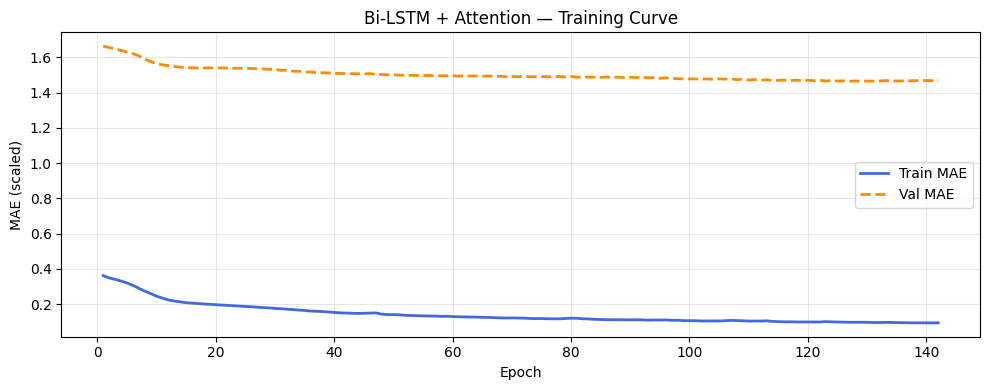

  Saved → data/processed/plots/bilstm_day_0.png


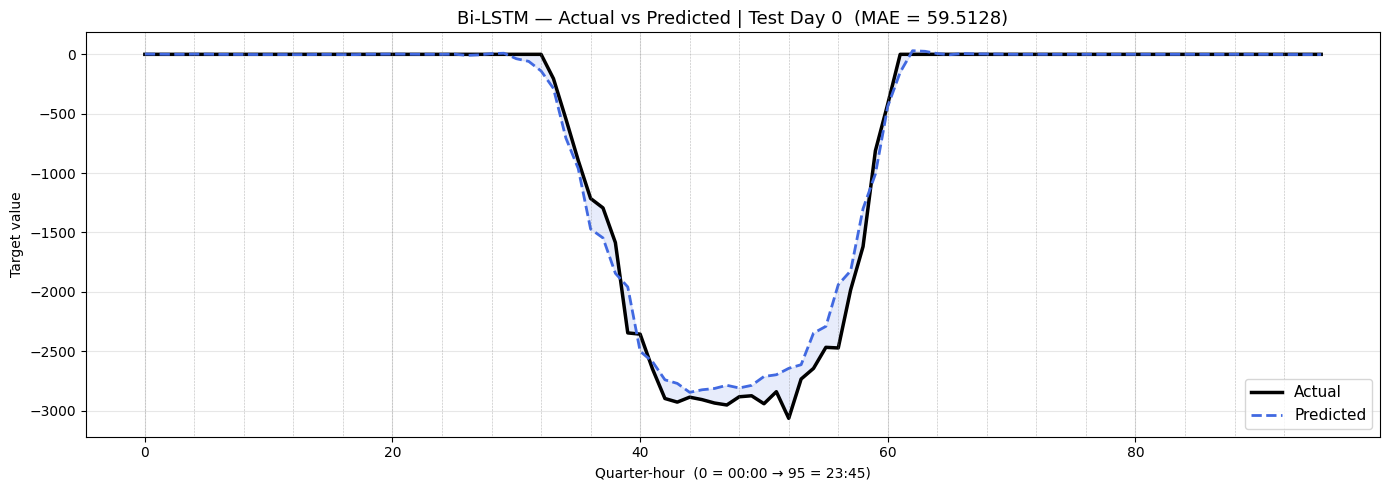

  Saved → data/processed/plots/bilstm_series_30days.png


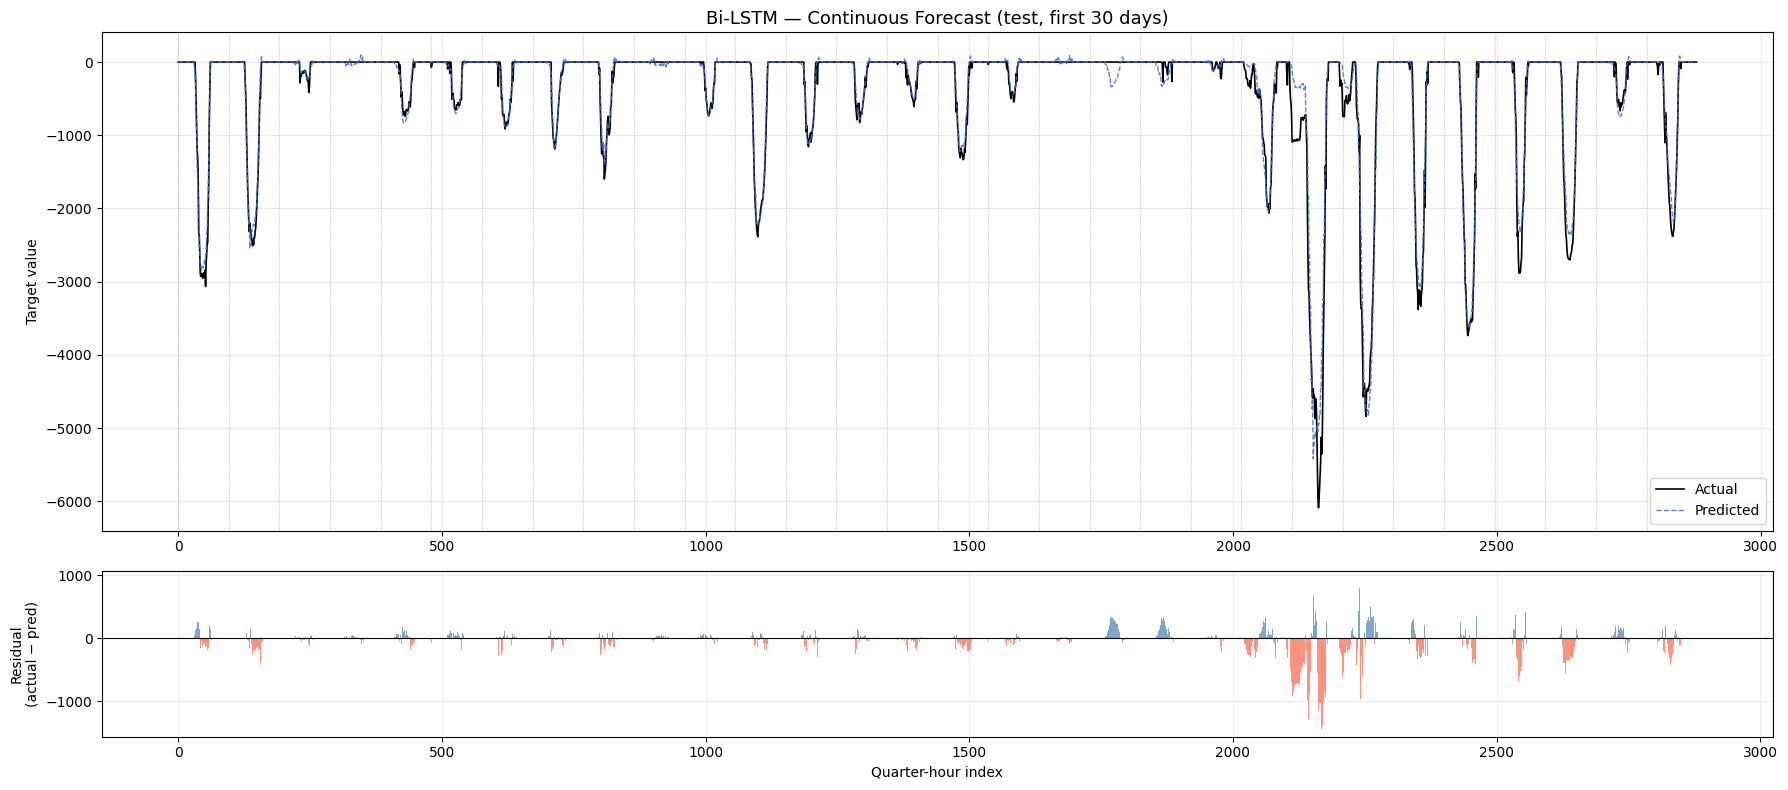


  Done.


In [45]:
if __name__ == "__main__":
    print(f"Device: {DEVICE}")

    # Load splits
    (X_train, y_train), (X_val, y_val), (X_test, y_test), y_test_raw, scaler_y = \
        load_splits()

    # Note: NO flattening here — Bi-LSTM keeps (n, 96, 7)
    print(f"Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")

    # DataLoaders
    train_loader = DataLoader(
        EnergyDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=False
    )
    val_loader = DataLoader(
        EnergyDataset(X_val, y_val), batch_size=BATCH_SIZE, shuffle=False
    )

    # Build model
    model = BiLSTMAttentionModel().to(DEVICE)

    # Train
    model, history = train(model, train_loader, val_loader)

    # Evaluate on validation set
    y_val_raw = scaler_y.inverse_transform(y_val)
    evaluate(model, X_val, y_val_raw, scaler_y, split_name="Validation")

    # Evaluate on test set
    y_pred = evaluate(model, X_test, y_test_raw, scaler_y, split_name="Test")


    # Save model
    save_model(model)

    # Plots
    plot_training_curve(history)
    plot_single_day(y_test_raw, y_pred, day_idx=0)
    plot_full_series(y_test_raw, y_pred, max_days=30)

    print("\n  Done.")